In [156]:
import os
import random

import numpy as np
import tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

# Quantization


In [157]:
def quantize(input_tensor, quantize_to_bits=8):
    @tf.custom_gradient
    def straight_through_estimator(input_tensor):
        max_int = (2 ** (quantize_to_bits - 1)) - 1
        max_float = tf.cast(max_int, tf.float32)
        max_val = tf.reduce_max(tf.abs(input_tensor))
        max_val = tf.maximum(max_val, 1e-8)

        scale = max_float / max_val

        quantized = tf.round(input_tensor * scale)
        quantized = tf.clip_by_value(quantized, -max_float, max_float)
        output = quantized / scale

        def grad(upstream, variables=None):
            if variables is not None:
                return upstream, [None] * len(variables)
            return upstream

        return output, grad

    return straight_through_estimator(input_tensor)

In [158]:
from keras.losses import mean_squared_error


def test_quantization():
    weights = tf.Variable([[1.02583, -0.238905], [-0.05612, -1.2983]], dtype=tf.float32)
    print("Original weights:\n", weights.numpy())

    target = tf.constant([[1.0, 1.0], [1.0, -1.0]], dtype=tf.float32)

    with tf.GradientTape() as tape:
        quantized_weights = quantize(weights, quantize_to_bits=4)
        loss = mean_squared_error(target, quantized_weights)
        loss = tf.reduce_mean(loss)

    gradients = tape.gradient(loss, weights)

    print("\nQuantized weights:\n", quantized_weights.numpy())
    print("\nGradients:\n", gradients.numpy())


test_quantization()

Original weights:
 [[ 1.02583  -0.238905]
 [-0.05612  -1.2983  ]]

Quantized weights:
 [[ 1.1128286  -0.18547143]
 [-0.         -1.2983    ]]

Gradients:
 [[ 0.05641431 -0.5927357 ]
 [-0.5        -0.14915001]]


# Model Constructing

## Custom Quantized Dense Layer


In [159]:
from keras.initializers import GlorotUniform
from keras.layers import Layer


class QuantizedDense(Layer):
    def __init__(self, units, quantize_to_bits=8, **kwargs):
        super(QuantizedDense, self).__init__(**kwargs)
        self.units = units
        self.quantize_to_bits = quantize_to_bits

    def build(self, input_shape):
        self.kernel = self.add_weight(
            name="kernel",
            shape=(input_shape[-1], self.units),
            initializer=GlorotUniform(seed=SEED),
            trainable=True,
        )

        self.bias = self.add_weight(
            name="bias", shape=(self.units,), initializer="zeros", trainable=True
        )

    def call(self, inputs):
        quantized_kernel = quantize(self.kernel, quantize_to_bits=self.quantize_to_bits)
        output = tf.matmul(inputs, quantized_kernel)
        output += self.bias
        return output

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.units)

    def get_config(self):
        config = super(QuantizedDense, self).get_config()
        config.update({"units": self.units, "quantize_to_bits": self.quantize_to_bits})
        return config

In [160]:
from keras import Input, Sequential

tf.random.set_seed(42)


def test_quantized_dense():
    model = Sequential([Input(shape=(4,)), QuantizedDense(units=3, quantize_to_bits=4)])

    test_input = tf.random.normal((2, 4))
    test_target = tf.random.normal((2, 3))

    with tf.GradientTape() as tape:
        predictions = model(test_input)
        loss = mean_squared_error(test_target, predictions)
        loss = tf.reduce_mean(loss)

    gradients = tape.gradient(loss, model.trainable_variables)

    print("\nTest X-Y:\n", f"X: {test_input.numpy()}\n", f"Y: {test_target.numpy()}")

    print("\nModel shape:\n", predictions.shape)
    print("\nWeights:\n", model.layers[0].kernel.numpy())
    print("\nGradients:\n", gradients[0].numpy())


test_quantized_dense()


Test X-Y:
 X: [[ 0.3274685 -0.8426258  0.3194337 -1.4075519]
 [-2.3880599 -1.0392479 -0.5573232  0.539707 ]]
 Y: [[ 0.08422458 -0.86090374  0.37812304]
 [-0.00519627 -0.49453196  0.6178192 ]]

Model shape:
 (2, 3)

Weights:
 [[-0.40285552 -0.00293136  0.39895165]
 [-0.8884132  -0.78028464  0.23434246]
 [ 0.4721651  -0.60510516 -0.6874906 ]
 [-0.8282933   0.81940484 -0.49910602]]

Gradients:
 [[-0.6428592  -1.6074047   1.3670007 ]
 [-0.9208706  -0.77439123  0.58027476]
 [ 0.00811617 -0.35666528  0.3226366 ]
 [-0.7225579   0.26192445 -0.32874054]]


## Positional Encoding Layer


In [161]:
from keras.initializers import Constant


class PositionalEncoding(Layer):
    def __init__(self, max_seq_len, dim_model, **kwargs):
        super(PositionalEncoding, self).__init__(**kwargs)
        self.max_seq_len = max_seq_len
        self.dim_model = dim_model

    def build(self, input_shape):
        position = np.arange(self.max_seq_len)[:, np.newaxis]
        i = np.arange(self.dim_model)[np.newaxis, :]

        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(self.dim_model))
        angle_rads = position * angle_rates
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        positional_encoding = angle_rads[np.newaxis, ...]
        positional_encoding = tf.cast(positional_encoding, tf.float32)
        # self.positional_encoding = self.add_weight(
        #     name="positional_encoding",
        #     shape=(1, self.max_seq_len, self.dim_model),
        #     initializer=Constant(positional_encoding),
        #     trainable=False,
        #     dtype=tf.float32,
        # )
        self.positional_encoding = tf.Variable(
            positional_encoding, trainable=False, dtype=tf.float32
        )
        # self.positional_encoding.assign(positional_encoding)
        super(PositionalEncoding, self).build(input_shape)

    def call(self, inputs):
        seq_len = tf.shape(inputs)[1]
        result = inputs + self.positional_encoding[:, :seq_len, :]
        return result

    def get_config(self):
        config = super(PositionalEncoding, self).get_config()
        config.update({"max_seq_len": self.max_seq_len, "dim_model": self.dim_model})
        return config

## Multi-Head Attention


In [162]:
class QuantizedMHA(Layer):
    def __init__(self, dim_model, head_num, quantize_to_bits=8, **kwargs):
        super(QuantizedMHA, self).__init__(**kwargs)
        self.dim_model = dim_model
        self.head_num = head_num
        self.quantize_to_bits = quantize_to_bits

        assert dim_model % head_num == 0, "dim_model must be divisible by head_num"

        self.depth = dim_model // head_num
        self.q_dense = QuantizedDense(
            units=dim_model, quantize_to_bits=quantize_to_bits, name="q_layer"
        )
        self.k_dense = QuantizedDense(
            units=dim_model, quantize_to_bits=quantize_to_bits, name="k_layer"
        )
        self.v_dense = QuantizedDense(
            units=dim_model, quantize_to_bits=quantize_to_bits, name="v_layer"
        )
        self.out_dense = QuantizedDense(
            units=dim_model, quantize_to_bits=quantize_to_bits, name="output_layer"
        )

    def split_head(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.head_num, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, q, k, v, mask=None):
        batch_size = tf.shape(q)[0]

        q = self.q_dense(q)
        k = self.k_dense(k)
        v = self.v_dense(v)

        q = self.split_head(q, batch_size)
        k = self.split_head(k, batch_size)
        v = self.split_head(v, batch_size)

        qk = tf.matmul(q, k, transpose_b=True)
        dim_k = tf.cast(self.depth, tf.float32)
        scaled_attention_logits = qk / tf.sqrt(dim_k)

        if mask is not None:
            scaled_attention_logits += mask * -1e9

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        output = tf.transpose(output, perm=[0, 2, 1, 3])
        attention = tf.reshape(output, (batch_size, -1, self.dim_model))

        return self.out_dense(attention)

# Forwarding


In [163]:
class ForwardingNetwork(Layer):
    def __init__(self, dim_model, dim_forward, quantize_to_bits=8, **kwargs):
        super(ForwardingNetwork, self).__init__(**kwargs)
        self.dense_1 = QuantizedDense(
            units=dim_forward, quantize_to_bits=quantize_to_bits, name="forward_1"
        )
        self.dense_2 = QuantizedDense(
            units=dim_model, quantize_to_bits=quantize_to_bits, name="forward_2"
        )

    def call(self, x):
        x = self.dense_1(x)
        x = tf.nn.gelu(x)
        return self.dense_2(x)

## Encoder-Decoder

- This one uses standard seq2seq architecture since it achieves higher accuracy for translation tasks


In [164]:
from keras.layers import LayerNormalization


class EncoderLayer(Layer):
    EPSILON = 1e-6

    def __init__(
        self,
        dim_model,
        dim_forward,
        head_num,
        quantize_to_bits=8,
        **kwargs,
    ):
        super(EncoderLayer, self).__init__(**kwargs)
        self.mha = QuantizedMHA(dim_model, head_num, quantize_to_bits)
        self.forwarding = ForwardingNetwork(dim_model, dim_forward, quantize_to_bits)
        self.layer_norm_1 = LayerNormalization(epsilon=self.EPSILON)
        self.layer_norm_2 = LayerNormalization(epsilon=self.EPSILON)

    def call(self, x, training=False, mask=None):
        attention = self.mha(x, x, x, mask)
        output_1 = self.layer_norm_1(x + attention)
        forwarding_output = self.forwarding(output_1)
        return self.layer_norm_2(output_1 + forwarding_output)


class DecoderLayer(Layer):
    EPSILON = 1e-6

    def __init__(
        self,
        dim_model,
        dim_forward,
        head_num,
        quantize_to_bits=8,
        **kwargs,
    ):
        super(DecoderLayer, self).__init__(**kwargs)
        self.mha_1 = QuantizedMHA(dim_model, head_num, quantize_to_bits)
        self.mha_2 = QuantizedMHA(dim_model, head_num, quantize_to_bits)
        self.forwarding = ForwardingNetwork(dim_model, dim_forward, quantize_to_bits)
        self.layer_norm_1 = LayerNormalization(epsilon=self.EPSILON)
        self.layer_norm_2 = LayerNormalization(epsilon=self.EPSILON)
        self.layer_norm_3 = LayerNormalization(epsilon=self.EPSILON)

    def call(
        self, x, encoder_output, training=False, look_ahead_mask=None, padding_mask=None
    ):
        attention_1 = self.mha_1(x, x, x, look_ahead_mask)
        output_1 = self.layer_norm_1(x + attention_1)

        attention_2 = self.mha_2(output_1, encoder_output, encoder_output, padding_mask)
        output_2 = self.layer_norm_2(output_1 + attention_2)

        forwarding_output = self.forwarding(output_2)
        return self.layer_norm_3(output_2 + forwarding_output)

In [165]:
def test_transformer():
    batch_size = 2
    seq_len = 10
    dim_model = 64
    head_num = 4
    dim_forward = 256

    test_x = tf.random.normal((batch_size, seq_len, dim_model))
    test_target = tf.random.normal((batch_size, seq_len, dim_model))
    encoder_layer = EncoderLayer(dim_model, dim_forward, head_num, quantize_to_bits=4)

    with tf.GradientTape() as tape:
        output = encoder_layer(test_x)
        loss = mean_squared_error(test_target, output)
        loss = tf.reduce_mean(loss)

    gradients = tape.gradient(loss, encoder_layer.trainable_variables)

    print("Encoder shape:\n", output.shape)
    print("\nTrainable weights len:\n", len(encoder_layer.trainable_variables))
    print("\nGradients:\n", gradients[0])


test_transformer()

Encoder shape:
 (2, 10, 64)

Trainable weights len:
 16

Gradients:
 tf.Tensor(
[[ 1.5084326e-05 -1.8236469e-04  9.5105241e-04 ...  2.8256129e-04
  -3.9297820e-04  1.0520481e-03]
 [-1.1419608e-03  9.9241745e-04  1.1402668e-03 ...  8.5978128e-05
   6.4438814e-04 -3.1716013e-04]
 [ 9.8247977e-04 -7.4364559e-04 -8.6312124e-04 ...  7.5836535e-05
  -1.0830747e-03 -9.4097405e-04]
 ...
 [-5.4140168e-04  7.6619594e-04  8.7510131e-04 ...  2.5792207e-04
   5.2954827e-04  7.0706895e-04]
 [-4.7694735e-04  1.7725823e-05  3.0002691e-04 ... -1.0720755e-03
   4.4371432e-04 -3.7527707e-04]
 [ 1.2542260e-03 -1.1563255e-03 -5.1076058e-04 ...  3.5782726e-04
  -1.5892095e-03  5.0757197e-04]], shape=(64, 64), dtype=float32)


## The Model Itself


In [166]:
def generate_padding_mask(seq):
    seq = tf.cast(tf.equal(seq, 0), tf.float32)
    return seq[:, tf.newaxis, tf.newaxis, :]


def generate_look_ahead_mask(seq_len):
    mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
    return mask[tf.newaxis, tf.newaxis, :, :]

In [167]:
from keras.layers import Embedding


class Encoder(Layer):
    def __init__(
        self,
        layer_num,
        head_num,
        dim_model,
        dim_forward,
        vocab_size,
        max_seq_len,
        quantize_to_bits=8,
        **kwargs,
    ):
        super(Encoder, self).__init__(**kwargs)
        self.dim_model = dim_model
        self.layer_num = layer_num

        self.embedding = Embedding(vocab_size, dim_model)
        self.positional_encoding = PositionalEncoding(max_seq_len, dim_model)

        self.encoder_layers = [
            EncoderLayer(dim_model, dim_forward, head_num, quantize_to_bits)
            for _ in range(layer_num)
        ]

    def call(self, x, training=False, mask=None):
        seq_len = tf.shape(x)[1]

        x = self.embedding(x)
        x *= tf.sqrt(tf.cast(self.dim_model, tf.float32))
        x = self.positional_encoding(x)

        for i in range(self.layer_num):
            x = self.encoder_layers[i](x, training=training, mask=mask)
        return x


class Decoder(Layer):
    def __init__(
        self,
        layer_num,
        head_num,
        dim_model,
        dim_forward,
        vocab_size,
        max_seq_len,
        quantize_to_bits=8,
        **kwargs,
    ):
        super(Decoder, self).__init__(**kwargs)
        self.dim_model = dim_model
        self.layer_num = layer_num

        self.embedding = Embedding(vocab_size, dim_model)
        self.positional_encoding = PositionalEncoding(max_seq_len, dim_model)

        self.decoder_layers = [
            DecoderLayer(dim_model, dim_forward, head_num, quantize_to_bits)
            for _ in range(layer_num)
        ]

    def call(
        self, x, encoder_output, training=False, look_ahead_mask=None, padding_mask=None
    ):
        seq_len = tf.shape(x)[1]

        x = self.embedding(x)
        x *= tf.sqrt(tf.cast(self.dim_model, tf.float32))
        x = self.positional_encoding(x)

        for i in range(self.layer_num):
            x = self.decoder_layers[i](
                x,
                encoder_output,
                training=training,
                look_ahead_mask=look_ahead_mask,
                padding_mask=padding_mask,
            )
        return x

In [168]:
from keras.models import Model


class PseudocodeTranslator(Model):
    def __init__(
        self,
        layer_num,
        head_num,
        dim_model,
        dim_forward,
        input_vocab_size,
        target_vocab_size,
        max_input_len,
        max_target_len,
        quantize_to_bits=8,
        **kwargs,
    ):
        super(PseudocodeTranslator, self).__init__(**kwargs)
        self.encoder = Encoder(
            layer_num,
            head_num,
            dim_model,
            dim_forward,
            vocab_size=input_vocab_size,
            max_seq_len=max_input_len,
            quantize_to_bits=quantize_to_bits,
        )
        self.decoder = Decoder(
            layer_num,
            head_num,
            dim_model,
            dim_forward,
            vocab_size=target_vocab_size,
            max_seq_len=max_target_len,
            quantize_to_bits=quantize_to_bits,
        )
        self.final_layer = QuantizedDense(
            units=target_vocab_size,
            quantize_to_bits=quantize_to_bits,
            name="vocab_projection",
        )

    def generate_mask(self, input, target):
        encoder_padding_mask = generate_padding_mask(input)
        decoder_padding_mask = generate_padding_mask(input)
        decoder_target_padding_mask = generate_padding_mask(target)

        look_ahead_mask = generate_look_ahead_mask(tf.shape(target)[1])
        combined_mask = tf.maximum(decoder_target_padding_mask, look_ahead_mask)

        return encoder_padding_mask, decoder_padding_mask, combined_mask

    def call(self, io_pair, training=False):
        input, target = io_pair

        encoder_padding_mask, decoder_padding_mask, combined_mask = self.generate_mask(
            input, target
        )

        encoder_output = self.encoder(
            input, training=training, mask=encoder_padding_mask
        )
        decoder_output = self.decoder(
            target,
            encoder_output,
            training=training,
            look_ahead_mask=combined_mask,
            padding_mask=decoder_padding_mask,
        )

        final_output = self.final_layer(decoder_output)
        return final_output

In [169]:
def test_model():
    batch_size = 2
    input_seq_len = 20
    target_seq_len = 30

    model = PseudocodeTranslator(
        layer_num=2,
        head_num=4,
        dim_model=128,
        dim_forward=512,
        input_vocab_size=1000,
        target_vocab_size=2000,
        max_input_len=100,
        max_target_len=100,
        quantize_to_bits=4,
    )

    model.summary()

    test_input = tf.random.uniform(
        (batch_size, input_seq_len), minval=1, maxval=1000, dtype=tf.int32
    )
    test_target = tf.random.uniform(
        (batch_size, target_seq_len), minval=1, maxval=2000, dtype=tf.int32
    )

    logits = model((test_input, test_target))

    print("Test input shape:\n", test_input.shape)
    print("\nTest target shape:\n", test_target.shape)
    print("\nLogits shape:\n", logits.shape)
    # Expected shape (2,30,2000)


test_model()

Model: "pseudocode_translator_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_9 (Encoder)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_9 (Decoder)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vocab_projection                │ ?                      │   0 (unbuilt) │
│ (QuantizedDense)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

c:\Users\shellbaby\miniconda3\envs\neural_network\Lib\site-packages\keras\src\layers\layer.py:1566: UserWarning: Layer 'pseudocode_translator_9' looks like it has unbuilt state, but Keras is not able to trace the layer `call()` in order to build it automatically. Possible causes:
1. The `call()` method of your layer may be crashing. Try to `__call__()` the layer eagerly on some test input first to see if it works. E.g. `x = np.random.random((3, 4)); y = layer(x)`
2. If the `call()` method is correct, then you may need to implement the `def build(self, input_shape)` method on your layer. It should create all variables used by the layer (e.g. by calling `layer.build()` on all its children layers).
Exception encountered: ''Exception encountered when calling Encoder.call().

Argument `initial_value` (Tensor("encoder_9_1/positional_encoding_18/Cast:0", shape=(1, 100, 128), dtype=float32)) could not be lifted out of a `tf.function`. (Tried to create variable with name='None'). To avoid this 

Test input shape:
 (2, 20)

Test target shape:
 (2, 30)

Logits shape:
 (2, 30, 2000)


# Synthetic AST

## Generator


In [170]:
from enum import IntEnum


class TYPE(IntEnum):
    assign = 1
    if_else = 2
    while_loop = 3
    for_loop = 4
    print_statement = 5


class ASTNode:
    pass


class Variable(ASTNode):
    def __init__(self, name):
        self.name = name


class Literal(ASTNode):
    def __init__(self, value):
        self.value = value


class BinaryOperation(ASTNode):
    def __init__(self, left, operator, right):
        self.left = left
        self.right = right
        self.operator = operator

    @classmethod
    def get_op(self, operator):
        op_map = {
            "+": "PLUS",
            "-": "MINUS",
            "*": "MULTIPLIED BY",
            "/": "DIVIDED BY",
            "==": "EQUALS",
            "!=": "DOES NOT EQUAL",
            ">": "IS GREATER THAN",
            ">=": "IS GREATER THAN OR EQUAL TO",
            "<": "IS LESS THAN",
            "<=": "IS LESS THAN OR EQUAL TO",
        }
        return op_map[operator]


class VariableAssignment(ASTNode):
    def __init__(self, target, expression, type=None, semicolon=True):
        self.type = type
        self.target = target
        self.expression = expression
        self.semicolon = semicolon


class Block(ASTNode):
    def __init__(self, statements):
        self.statements = statements


class IfStatement(ASTNode):
    def __init__(self, condition, if_block, else_block=None):
        self.condition = condition
        self.if_block = if_block
        self.else_block = else_block


class WhileLoop(ASTNode):
    def __init__(self, condition, body):
        self.condition = condition
        self.body = body


class ForLoop(ASTNode):
    def __init__(self, init, condition, update, body):
        self.init = init
        self.condition = condition
        self.update = update
        self.body = body


class PrintStatement(ASTNode):
    def __init__(self, expression):
        self.expression = expression

In [171]:
def to_pseudocode(node: ASTNode):
    if isinstance(node, Variable):
        return node.name
    if isinstance(node, Literal):
        return node.value

    if isinstance(node, BinaryOperation):
        return f"{to_pseudocode(node.left)} {BinaryOperation.get_op(node.operator)} {to_pseudocode(node.right)}"

    if isinstance(node, VariableAssignment):
        return f"SET {node.target.name} TO {to_pseudocode(node.expression)}"

    if isinstance(node, Block):
        return " ".join([to_pseudocode(statement) for statement in node.statements])

    if isinstance(node, IfStatement):
        code = f"IF {to_pseudocode(node.condition)} THEN {to_pseudocode(node.if_block)}"
        if node.else_block:
            code += f" ELSE {to_pseudocode(node.else_block)}"
        return code + " END IF"

    if isinstance(node, WhileLoop):
        return f"WHILE {to_pseudocode(node.condition)} DO {to_pseudocode(node.body)} END WHILE"

    if isinstance(node, ForLoop):
        return f"FOR {to_pseudocode(node.init)} WHILE {to_pseudocode(node.condition)} UPDATE {to_pseudocode(node.update)} DO {to_pseudocode(node.body)} END FOR"

    if isinstance(node, PrintStatement):
        return f"PRINT {to_pseudocode(node.expression)}"


def to_csharp(node):
    if isinstance(node, Variable):
        return node.name
    if isinstance(node, Literal):
        return str(node.value)

    if isinstance(node, BinaryOperation):
        return f"{to_csharp(node.left)} {node.operator} {to_csharp(node.right)}"

    if isinstance(node, VariableAssignment):
        var_type = f"{node.type} " if node.type else ""
        semicolon = f" ;" if node.semicolon else ""
        return f"{var_type}{node.target.name} = {to_csharp(node.expression)}{semicolon}"

    if isinstance(node, Block):
        return " ".join([to_csharp(statement) for statement in node.statements])

    if isinstance(node, IfStatement):
        code = f"if ( {to_csharp(node.condition)} ) {{ {to_csharp(node.if_block)} }}"
        if node.else_block:
            code += f" else {{ {to_csharp(node.else_block)} }}"
        return code

    if isinstance(node, WhileLoop):
        return f"while ( {to_csharp(node.condition)} ) {{ {to_csharp(node.body)} }}"

    if isinstance(node, ForLoop):
        return f"for ( {to_csharp(node.init)} {to_csharp(node.condition)} ; {to_csharp(node.update)} ) {{ {to_csharp(node.body)} }}"

    if isinstance(node, PrintStatement):
        return f"Console.WriteLine ( {to_csharp(node.expression)} ) ;"

In [172]:
VAR_NAMES = ["x", "y", "z", "count", "total", "result", "a", "b", "c", "i", "j", "k"]
MATH_OPS = ["+", "-", "*", "/"]
COMPARISON_OPS = ["==", "!=", ">", ">=", "<", "<="]


def generate_expression():
    if random.random() > 0.5:
        left = Variable(random.choice(VAR_NAMES))
        right = Literal(random.randint(1, 100))
        operator = random.choice(MATH_OPS)
        return BinaryOperation(left, operator, right)
    return Literal(random.randint(1, 100))


def generate_condition(target=None):
    left = target if target else Variable(random.choice(VAR_NAMES))
    right = Literal(random.randint(1, 100))
    operator = random.choice(COMPARISON_OPS)
    return BinaryOperation(left, operator, right)


def generate_block(depth, max_depth, min_statement=1, max_statement=3):
    if depth >= max_depth:
        return Block([generate_statement(depth, max_depth)])

    statement_num = random.randint(min_statement, max_statement)
    return Block([generate_statement(depth, max_depth) for _ in range(statement_num)])


def generate_statement(depth=0, max_depth=3):
    if depth >= max_depth:
        target = Variable(random.choice(VAR_NAMES))
        return VariableAssignment(target, generate_expression(), type="int")

    ast_type = random.choice(list(TYPE))

    if ast_type.name == "assign":
        target = Variable(random.choice(VAR_NAMES))
        return VariableAssignment(target, generate_expression(), type="int")

    elif ast_type.name == "if_else":
        condition = generate_condition()
        if_block = Block([generate_statement(depth + 1, max_depth)])
        else_block = (
            generate_block(depth + 1, max_depth) if random.random() > 0.5 else None
        )
        return IfStatement(condition, if_block, else_block)

    elif ast_type.name == "while_loop":
        condition = generate_condition()
        body = generate_block(depth + 1, max_depth)
        return WhileLoop(condition, body)

    elif ast_type.name == "for_loop":
        iterator = Variable(random.choice(VAR_NAMES))
        init = VariableAssignment(iterator, Literal(random.randint(1, 10)), type="int")
        condition = generate_condition(target=iterator)
        update = BinaryOperation(iterator, "+", Literal(random.randint(1, 10)))
        update = VariableAssignment(iterator, update, type=None, semicolon=False)
        body = generate_block(depth + 1, max_depth)

        return ForLoop(init, condition, update, body)

    elif ast_type.name == "print_statement":
        return PrintStatement(generate_expression())


def generate_synthetic_pseudocode(samples=1000, max_depth=3):
    dataset: list[tuple] = []

    for _ in range(samples):
        statement_num = random.randint(1, 3)
        root = Block(
            [
                generate_statement(depth=0, max_depth=max_depth)
                for _ in range(statement_num)
            ]
        )
        dataset.append((to_pseudocode(root), f"<START> {to_csharp(root)} <END>"))
    return dataset


def print_dataset(dataset: list[tuple], samples=10):
    for i, (pseudocode, real_code) in enumerate(dataset):
        if i >= samples:
            break
        print(f"\nPseudocode:\n", pseudocode)
        print(f"\nReal code:\n", real_code)


sample = generate_synthetic_pseudocode(samples=1)
print_dataset(dataset=sample)


Pseudocode:
 WHILE count DOES NOT EQUAL 29 DO SET j TO c DIVIDED BY 12 SET x TO 30 PRINT c DIVIDED BY 26 END WHILE

Real code:
 <START> while ( count != 29 ) { int j = c / 12 ; int x = 30 ; Console.WriteLine ( c / 26 ) ; } <END>


## Tokenization


In [173]:
from keras.layers import TextVectorization


def standardize(input):
    standardized = tf.strings.lower(input)
    standardized = tf.strings.regex_replace(standardized, r"(==|!=|>=|<=)", r" \1 ")
    standardized = tf.strings.regex_replace(
        standardized, r"([;=+\-*/(){}><!])", r" \1 "
    )
    standardized = tf.strings.regex_replace(standardized, r"\s+", " ")
    return standardized


def tokenizer(dataset, vocab_size=1000, max_seq_len=100):
    pseudocode = [pair[0] for pair in dataset]
    real_code = [pair[1] for pair in dataset]

    pseudocode_vectorizer = TextVectorization(
        max_tokens=vocab_size,
        output_sequence_length=max_seq_len,
        standardize=standardize,
        split="whitespace",
    )

    real_code_vectorizer = TextVectorization(
        max_tokens=vocab_size,
        output_sequence_length=max_seq_len,
        standardize=standardize,
        split="whitespace",
    )

    pseudocode_vectorizer.adapt(pseudocode)
    real_code_vectorizer.adapt(real_code)

    return pseudocode_vectorizer, real_code_vectorizer

In [174]:
def test_standardization():
    test_code = "int x = 45;\nConsole.Writeline(x);"
    standardized = standardize(test_code)
    print(f"Original:\n{test_code}")
    print(f"\nStandardized: {standardized}")


test_standardization()

Original:
int x = 45;
Console.Writeline(x);

Standardized: b'int x = 45 ; console.writeline ( x ) ; '


# Training


In [175]:
from keras.losses import SparseCategoricalCrossentropy

sparse_cat_crossentropy = SparseCategoricalCrossentropy(
    from_logits=True, reduction="none"
)


def custom_loss(target, prediction):
    loss = sparse_cat_crossentropy(target, prediction)
    mask = tf.logical_not(tf.equal(target, 0))
    mask = tf.cast(mask, dtype=loss.dtype)
    loss *= mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)


def custom_accuracy(target, prediction):
    prediction_tokens = tf.argmax(prediction, axis=-1)
    prediction_tokens = tf.cast(prediction_tokens, target.dtype)

    match = tf.cast(tf.equal(target, prediction_tokens), tf.float32)
    mask = tf.logical_not(tf.equal(target, 0))
    mask = tf.cast(mask, tf.float32)
    match *= mask

    return tf.reduce_sum(match) / tf.reduce_sum(mask)


In [176]:
from keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-4, beta_1=0.9, beta_2=0.9, epsilon=1e-9)


@tf.function
def train_step(model, input, target_input, target_real):
    with tf.GradientTape() as tape:
        predictions = model((input, target_input), training=True)
        loss = custom_loss(target_real, predictions)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    accuracy = custom_accuracy(target_real, predictions)

    return loss, accuracy

In [177]:
import os
import time


def start_training(
    model,
    train_set,
    validation_set,
    epochs=10,
    eval_freq=500,
    checkpoint_dir="./checkpoints",
):
    os.makedirs(checkpoint_dir, exist_ok=True)
    path = os.path.join(checkpoint_dir, "best.weights.h5")
    history = {
        "batch_loss": [],
        "batch_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_steps": [],
    }

    best_val_loss = float("inf")
    global_batch = 0
    fixed_val_set = validation_set.take(64).cache()

    for epoch in range(epochs):
        start_time = time.time()
        train_loss = 0.0
        train_acc = 0.0
        train_batches = 0

        for batch, ((input, target_input), target_real) in enumerate(train_set):
            batch_loss, batch_acc = train_step(model, input, target_input, target_real)

            history["batch_loss"].append(batch_loss)
            history["batch_accuracy"].append(batch_acc)
            global_batch += 1

            train_loss += batch_loss
            train_acc += batch_acc
            train_batches += 1

            if global_batch % eval_freq == 0:
                val_loss = 0.0
                val_acc = 0.0
                val_batches = 0

                for (input, target_input), target_real in fixed_val_set:
                    predictions = model((input, target_input), training=False)
                    val_loss += custom_loss(target_real, predictions)
                    val_acc += custom_accuracy(target_real, predictions)
                    val_batches += 1

                batch_val_loss = val_loss / val_batches
                batch_val_acc = val_acc / val_batches

                history["val_steps"].append(global_batch)
                history["val_loss"].append(batch_val_loss)
                history["val_accuracy"].append(batch_val_acc)

                print(
                    f"Epoch {epoch + 1} - Batch {batch} | "
                    f"Train loss: {batch_loss:.4f} | "
                    f"Train accuracy: {batch_acc:.4f} | "
                    f"Val loss: {batch_val_loss:.4f} | "
                    f"Val accuracy: {batch_val_acc:.4f}"
                )

                if batch_val_loss < best_val_loss:
                    print(
                        f"Save best validation loss at epoch {epoch}, batch {train_batches}"
                    )
                    best_val_loss = batch_val_loss
                    model.save_weights(path)

        elapsed_time = time.time() - start_time
        print(f"\nEpoch {epoch + 1} finished in {elapsed_time:.2f}s")

    return history

In [178]:
def make_dataset(
    raw,
    source_tokenizer: TextVectorization,
    target_tokenizer: TextVectorization,
    batch_size,
):
    pseudocode, real_code = zip(*raw)

    source_tensor = source_tokenizer(list(pseudocode))
    target_tensor = target_tokenizer(list(real_code))

    decoder_input = target_tensor[:, :-1]
    decoder_output = target_tensor[:, 1:]

    dataset = tf.data.Dataset.from_tensor_slices(
        ((source_tensor, decoder_input), decoder_output)
    )
    dataset = dataset.cache()
    dataset = dataset.shuffle(buffer_size=20000)
    dataset = dataset.batch(batch_size, drop_remainder=True)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


def build_dataset(samples, max_seq_len, batch_size):
    dataset = generate_synthetic_pseudocode(samples, max_depth=5)

    print_dataset(dataset, samples=2)

    train_size = int(samples * 0.8)
    validation_size = int(samples * 0.1)

    train_set = dataset[:train_size]
    validation_set = dataset[train_size : train_size + validation_size]
    test_set = dataset[train_size + validation_size :]

    # print(len(train_set), len(validation_set), len(test_set))

    pseudocode_tokens, real_code_tokens = tokenizer(train_set, max_seq_len=max_seq_len)

    train_set = make_dataset(train_set, pseudocode_tokens, real_code_tokens, batch_size)
    validation_set = make_dataset(
        validation_set, pseudocode_tokens, real_code_tokens, batch_size
    )
    test_set = make_dataset(test_set, pseudocode_tokens, real_code_tokens, batch_size)

    return train_set, validation_set, test_set, pseudocode_tokens, real_code_tokens


In [179]:
MAX_SEQ_LEN = 200
BATCH_SIZE = 64
SAMPLES = 300000

train_set, validation_set, test_set, pseudocode_tokens, real_code_tokens = (
    build_dataset(samples=SAMPLES, max_seq_len=MAX_SEQ_LEN, batch_size=BATCH_SIZE)
)


Pseudocode:
 FOR SET i TO 5 WHILE i DOES NOT EQUAL 1 UPDATE SET i TO i PLUS 7 DO WHILE z IS GREATER THAN 28 DO SET a TO 45 END WHILE PRINT 6 END FOR

Real code:
 <START> for ( int i = 5 ; i != 1 ; i = i + 7 ) { while ( z > 28 ) { int a = 45 ; } Console.WriteLine ( 6 ) ; } <END>

Pseudocode:
 FOR SET c TO 2 WHILE c EQUALS 49 UPDATE SET c TO c PLUS 9 DO PRINT result MINUS 74 SET x TO total MINUS 11 END FOR SET a TO 82 WHILE z IS GREATER THAN 48 DO WHILE k IS LESS THAN OR EQUAL TO 88 DO PRINT c MINUS 94 END WHILE END WHILE

Real code:
 <START> for ( int c = 2 ; c == 49 ; c = c + 9 ) { Console.WriteLine ( result - 74 ) ; int x = total - 11 ; } int a = 82 ; while ( z > 48 ) { while ( k <= 88 ) { Console.WriteLine ( c - 94 ) ; } } <END>


In [180]:
model = PseudocodeTranslator(
    layer_num=4,
    head_num=8,
    dim_model=128,
    dim_forward=512,
    input_vocab_size=1000,
    target_vocab_size=1500,
    max_input_len=MAX_SEQ_LEN,
    max_target_len=MAX_SEQ_LEN,
    quantize_to_bits=8,
)

In [181]:
history = start_training(model, train_set, validation_set, epochs=2)

c:\Users\shellbaby\miniconda3\envs\neural_network\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'encoder_layer_35' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
c:\Users\shellbaby\miniconda3\envs\neural_network\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'encoder_layer_36' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
c:\Users\shellbaby\miniconda3\envs\neural_network\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'encoder_layer_37' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destr

Epoch 1 - Batch 499 | Train loss: 1.6973 | Train accuracy: 0.5483 | Val loss: 1.6836 | Val accuracy: 0.5495
Save best validation loss at epoch 0, batch 500
Epoch 1 - Batch 999 | Train loss: 1.3567 | Train accuracy: 0.6113 | Val loss: 1.3510 | Val accuracy: 0.6109
Save best validation loss at epoch 0, batch 1000
Epoch 1 - Batch 1499 | Train loss: 1.2473 | Train accuracy: 0.6324 | Val loss: 1.2362 | Val accuracy: 0.6329
Save best validation loss at epoch 0, batch 1500
Epoch 1 - Batch 1999 | Train loss: 1.0099 | Train accuracy: 0.7083 | Val loss: 1.0399 | Val accuracy: 0.7008
Save best validation loss at epoch 0, batch 2000
Epoch 1 - Batch 2499 | Train loss: 0.8567 | Train accuracy: 0.7611 | Val loss: 0.8621 | Val accuracy: 0.7578
Save best validation loss at epoch 0, batch 2500
Epoch 1 - Batch 2999 | Train loss: 0.7414 | Train accuracy: 0.8063 | Val loss: 0.7487 | Val accuracy: 0.8003
Save best validation loss at epoch 0, batch 3000
Epoch 1 - Batch 3499 | Train loss: 0.5129 | Train accur

# Validation


In [188]:
import matplotlib.pyplot as plt


def plot_history(history, smoothing_window=100):
    train_steps = range(1, len(history["batch_loss"]) + 1)
    val_steps = history["val_steps"]

    def smooth(data, window_size):
        if len(data) < window_size:
            return data
        return np.convolve(data, np.ones(window_size) / window_size, mode="valid")

    smooth_loss = smooth(history["batch_loss"], smoothing_window)
    smooth_acc = smooth(history["batch_accuracy"], smoothing_window)
    smooth_steps = range(smoothing_window, len(history["batch_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(train_steps, history["batch_loss"], "b-", label="Batch loss", alpha=0.2)
    ax1.plot(smooth_steps, smooth_loss, "b-", label="Smoothed batch loss", linewidth=2)
    ax1.plot(val_steps, history["val_loss"], "r--", label="Val loss", linewidth=2)
    ax1.set_title("Training and validation loss per batch", fontsize=14)
    ax1.set_xlabel("Batch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)
    ax1.legend(loc="upper right")
    ax1.grid(True, linestyle=":", alpha=0.7)

    ax2.plot(
        train_steps, history["batch_accuracy"], "b-", label="Batch accuracy", alpha=0.2
    )
    ax2.plot(
        smooth_steps, smooth_acc, "b-", label="Smoothed batch accuracy", linewidth=2
    )
    ax2.plot(
        val_steps, history["val_accuracy"], "r--", label="Val accuracy", linewidth=2
    )
    ax2.set_title("Training and validation accuracy per batch", fontsize=14)
    ax2.set_xlabel("Epochs", fontsize=12)
    ax2.set_ylabel("Loss", fontsize=12)
    ax2.legend(loc="lower right")
    ax2.grid(True, linestyle=":", alpha=0.7)

    plt.tight_layout()
    plt.show()

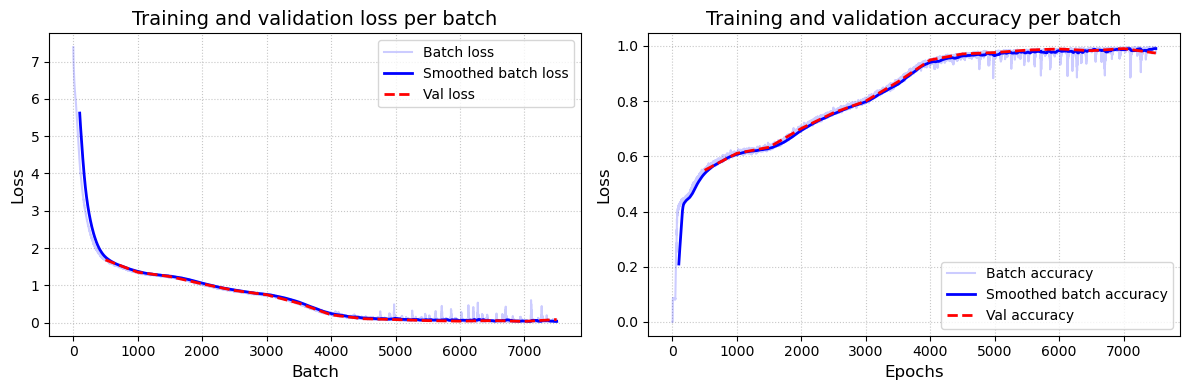

In [189]:
plot_history(history)

# Inference


In [184]:
def translate(
    model,
    input,
    source_tokenizer: TextVectorization,
    target_tokenizer: TextVectorization,
    max_target_len=MAX_SEQ_LEN,
):
    input_tensor = source_tokenizer([input])
    target_vocab = target_tokenizer.get_vocabulary()

    try:
        start_token = target_vocab.index("<START>")
        end_token = target_vocab.index("<END>")
    except ValueError:
        raise ValueError("Start and end tokens are missing in vocab")

    decoder_input = tf.convert_to_tensor([[start_token]], dtype=tf.int64)
    output_token_ids = []

    for i in range(max_target_len):
        predictions = model((input_tensor, decoder_input), training=False)
        next_token_logits = predictions[0, -1, :]
        next_token_id = tf.argmax(next_token_logits).numpy()

        if next_token_id == end_token:
            break

        output_token_ids.append(next_token_id)
        next_token_tensor = tf.convert_to_tensor([[next_token_id]], dtype=tf.int64)
        decoder_input = tf.concat([decoder_input, next_token_tensor], axis=-1)

    to_readable = {i: word for i, word in enumerate(target_vocab)}
    translated = []

    for token_id in output_token_ids:
        word = to_readable.get(token_id, "")
        if word not in ["", "[UNK]"]:
            translated.append(word)

    return " ".join(translated)

In [185]:
# int rows = 5;
# for (int i = 1; i <= rows; i++)
# {
#     for (int j = 1; j <= i; j++)
#     {
#         Console.Write("*");
#     }
#     Console.WriteLine();
# }

# SET c TO 84 FOR SET count TO 8 WHILE count IS GREATER THAN 76 UPDATE SET count TO count PLUS 1 DO IF k IS GREATER THAN

test_pseudocode = "SET rows TO 5 FOR SET i TO 1 WHILE i IS LESS THAN OR EQUAL TO rows UPDATE SET i TO i PLUS 1 DO FOR SET j TO 1 WHILE j IS LESS THAN OR EQUAL TO i UPDATE SET j TO j PLUS 1 PRINT 1 END FOR PRINT 0 END FOR"